# Supplementary Material 3
[Insert Article Title Here]

Submitted to: [Insert Journal Name Here]

Jorge Lizarazo¹, Gustavo A. Londoño², Judit Ungvari Martin³ ⁴, Justin Baldwin⁵ & Scott K. Robinson⁶

¹ Center for Animals on the Move, Department of Biology, Western University, London, ON, Canada
² Department of Biological Sciences, Bioprocesses and Biotechnology, Icesi University, Cali, Colombia
³ Future Earth Global Secretariat, New York, NY, USA
⁴ Institute for a Sustainable Earth, George Mason University, Fairfax, VA, USA
⁵ Department of Ecology and Evolutionary Biology, University of California, Santa Cruz, USA
⁶ Florida Museum of Natural History, University of Florida, Gainesville, Florida, USA

Corresponding authors:

Jorge Lizarazo  Jorge.lizarazo.b@gmail.com &
Gustavo A. Londoño  galondono@icesi.edu.co

Incubation events identified by the behavioural detection pipeline were imported for all nests.
Each file corresponds to a single nest and contains the start time, end time, and behavioural classification of each incubation interval given by a label process in Label-Studio.
Events were combined into a single dataset and standardized time variables were derived from event start timestamps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import datetime

In [2]:
new_one_path = 'dd/Finale'

all_data_frames = []

for filename in os.listdir(new_one_path):
    if '_analizado_finale.csv' in filename:
        df = pd.read_csv(os.path.join(new_one_path, filename))

        df['Start'] = pd.to_datetime(df['Start'])
        df['End'] = pd.to_datetime(df['End'])

        df['Día'] = df['Start'].dt.date
        df['Month_Nest'] = df['Start'].dt.strftime('%B')

        nest_id = filename.replace('_analizado_finale.csv', '')
        df['Nest_ID'] = nest_id

        all_data_frames.append(df)

final_df = pd.concat(all_data_frames, ignore_index=True)

## S3.1 Correcting Events that Span Midnight

Some incubation events extend across midnight and therefore span two calendar days.
To ensure that daily behavioural signals accurately represent a single day, events crossing midnight were divided into separate segments so that each segment belongs entirely to one calendar day.

In [3]:
def split_cross_midnight(df):

    new_rows = []

    for _, row in df.iterrows():

        start = row['Start']
        end = row['End']

        if start.date() == end.date():
            new_rows.append(row)
            continue

        current_start = start

        while current_start.date() < end.date():

            end_of_day = pd.Timestamp(
                year=current_start.year,
                month=current_start.month,
                day=current_start.day,
                hour=23,
                minute=59,
                second=59
            )

            new_row = row.copy()
            new_row['Start'] = current_start
            new_row['End'] = end_of_day
            new_row['Duración (min)'] = (
                (end_of_day - current_start).total_seconds() / 60
            )

            new_rows.append(new_row)

            current_start = end_of_day + pd.Timedelta(seconds=1)

        new_row = row.copy()
        new_row['Start'] = current_start
        new_row['End'] = end
        new_row['Duración (min)'] = (
            (end - current_start).total_seconds() / 60
        )

        new_rows.append(new_row)

    return pd.DataFrame(new_rows)

final_df = split_cross_midnight(final_df)

final_df['Día'] = final_df['Start'].dt.date

## S3.2 Removal of Incomplete Nest-Days

Only nest-days with nearly complete temporal coverage were retained for rhythm analysis.

Daily coverage was calculated as the total duration of all events recorded within each nest-day.
Days with less than 24 hours of recorded data (±5 minutes tolerance) were removed to avoid artefacts in the temporal signal reconstruction.

In [4]:
# eliminar días incompletos (menos de 24h registradas)

daily_coverage = (
    final_df
    .groupby(['Nest_ID','Día'])['Duración (min)']
    .sum()
    .reset_index()
)

daily_coverage.rename(
    columns={'Duración (min)': 'minutes_recorded'},
    inplace=True
)

tolerance = 5  # minutos de tolerancia

complete_days = daily_coverage[
    np.abs(daily_coverage['minutes_recorded'] - 1440) <= tolerance
]

final_df = final_df.merge(
    complete_days[['Nest_ID','Día']],
    on=['Nest_ID','Día'],
    how='inner'
)

print("Total days:", len(daily_coverage))
print("Complete days:", len(complete_days))
print("Removed days:", len(daily_coverage) - len(complete_days))

Total days: 689
Complete days: 519
Removed days: 170


We convert each retained nest-day into a 1,440-minute binary signal, sample random days for raster plots, and compute autocorrelations plus spectral entropy/strength so the dominant rhythm and its monthly trends are apparent.

## S3.3 Construction of Minute-Resolution Daily Signals

Each retained nest-day was converted into a binary time series of 1,440 minutes.

For each minute of the day:

1 = incubating (On or Nocturnal interval)
0 = not incubating (Off bout)

This transformation allows incubation behaviour to be analysed as a continuous temporal signal suitable for rhythm detection and spectral analysis.

In [5]:
def build_daily_signal(group):

    signal = np.zeros(1440)

    for _, row in group.iterrows():

        start_min = row['Start'].hour * 60 + row['Start'].minute
        end_min = row['End'].hour * 60 + row['End'].minute + 1

        if row['Tipo'] in ['On','Nocturnal']:
            signal[start_min:end_min] = 1

    return signal

In [6]:
daily_signals = {}

for (nest, day), group in final_df.groupby(['Nest_ID','Día']):
    daily_signals[(nest, day)] = build_daily_signal(group)

In [7]:
import random

In [8]:
n_days = 30  # cuantos días visualizar
keys = list(daily_signals.keys())

sample_keys = random.sample(keys, min(n_days, len(keys)))

In [9]:
matrix = np.array([daily_signals[k] for k in sample_keys])

## S3.4 Visualization of Incubation Activity Patterns

To visualize daily behavioural structure, random nest-days were sampled and plotted as raster diagrams.
Each row represents a single nest-day and each column corresponds to one minute of the day.

Black segments represent periods of incubation and white segments represent recess intervals.

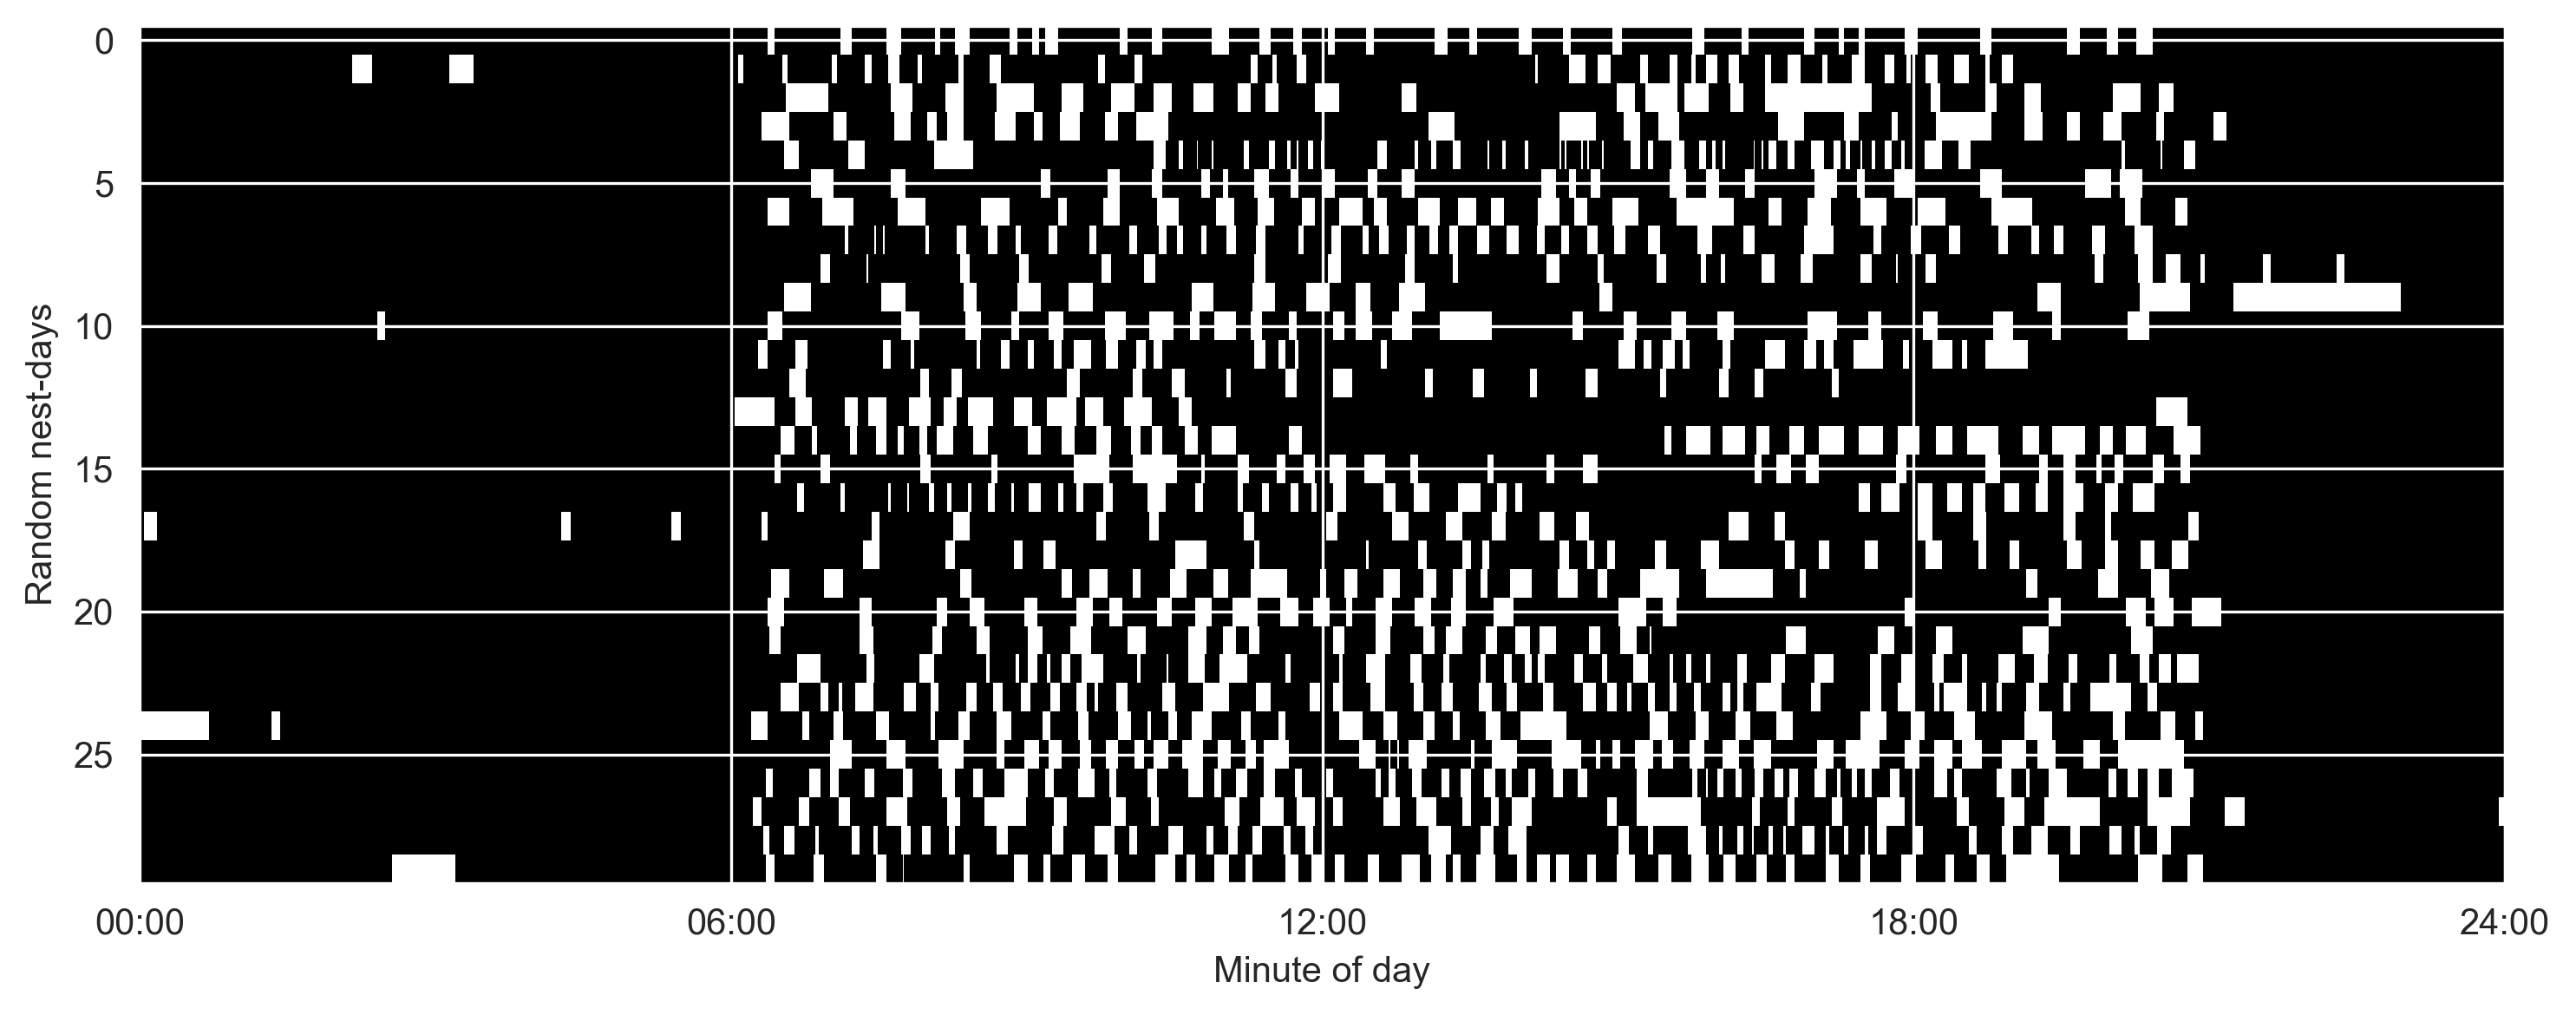

In [10]:
fig, ax = plt.subplots(figsize=(10,4), dpi=300)

ax.imshow(
    matrix,
    aspect='auto',
    cmap='binary',  # blanco/negro
    interpolation='nearest'
)

ax.set_xlabel("Minute of day")
ax.set_ylabel("Random nest-days")

ax.set_xticks([0, 360, 720, 1080, 1440])
ax.set_xticklabels(["00:00","06:00","12:00","18:00","24:00"])

plt.tight_layout()
plt.show()

### S3.4.1 Detection of Dominant Incubation Rhythms

The dominant incubation rhythm of each nest-day was estimated using autocorrelation analysis.
The lag corresponding to the highest autocorrelation peak within a biologically plausible window (10–360 minutes) was interpreted as the dominant behavioural cycle.

To quantify the regularity of the rhythm, two spectral metrics were also calculated:

- Periodicity strength - proportion of spectral power contained in the dominant frequency
- Spectral entropy - distribution of spectral power across frequencies, representing rhythm complexity

In [11]:
def autocorr(signal):
    signal = signal - np.mean(signal)
    result = np.correlate(signal, signal, mode='full')
    result = result[result.size // 2:]
    result = result / result[0]
    return result

In [12]:
def spectral_metrics(signal):

    signal = signal - np.mean(signal)

    fft_vals = np.fft.rfft(signal)
    power = np.abs(fft_vals)**2

    freqs = np.fft.rfftfreq(len(signal), d=1)

    # ignorar frecuencia 0
    power = power[1:]
    freqs = freqs[1:]

    # fuerza del pico dominante
    peak_idx = np.argmax(power)
    peak_power = power[peak_idx]

    strength = peak_power / np.sum(power)

    # spectral entropy
    p = power / np.sum(power)
    entropy = -np.sum(p * np.log(p + 1e-12))

    return strength, entropy

In [13]:
periods = []

for key, signal in daily_signals.items():

    ac = autocorr(signal)

    min_lag = 10
    max_lag = 360

    search_region = ac[min_lag:max_lag]
    lag = np.argmax(search_region) + min_lag

    period_minutes = lag
    period_hours = lag / 60

    strength, entropy = spectral_metrics(signal)

    periods.append({
        "Nest_ID": key[0],
        "Day": key[1],
        "Period_minutes": period_minutes,
        "Period_hours": period_hours,
        "Periodicity_strength": strength,
        "Spectral_entropy": entropy
    })

period_df = pd.DataFrame(periods)

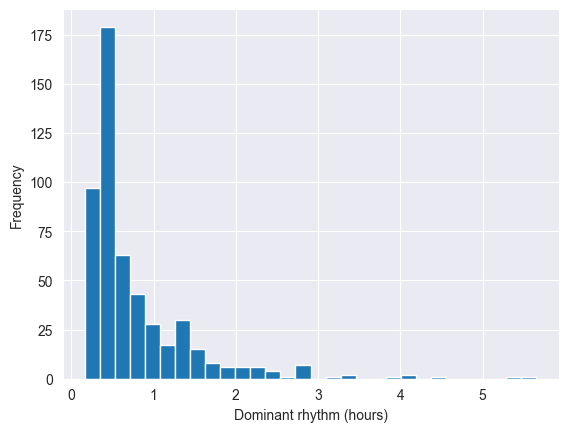

In [14]:
plt.hist(period_df["Period_hours"], bins=30)
plt.xlabel("Dominant rhythm (hours)")
plt.ylabel("Frequency")
plt.show()

### S3.4.2 Seasonal Patterns in Incubation Rhythms

Temporal changes in incubation rhythms across the breeding season were explored by examining how dominant period length and rhythm strength vary with calendar date and breeding month.

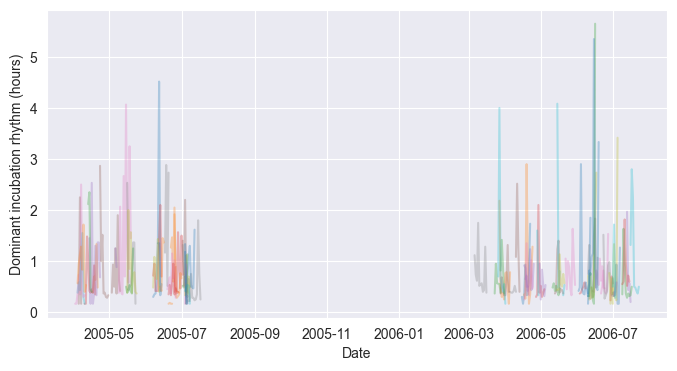

In [15]:
period_df["Day"] = pd.to_datetime(period_df["Day"])

period_df = period_df.sort_values(["Nest_ID","Day"])

plt.figure(figsize=(8,4))

for nest, g in period_df.groupby("Nest_ID"):
    plt.plot(g["Day"], g["Period_hours"], alpha=0.3)

plt.ylabel("Dominant incubation rhythm (hours)")
plt.xlabel("Date")
plt.show()

In [16]:
period_df["Month"] = period_df["Day"].dt.month
period_df["Month_name"] = period_df["Day"].dt.strftime("%B")

In [17]:
period_df["Month"] = period_df["Day"].dt.month
period_df["Month_name"] = period_df["Day"].dt.strftime("%b")
period_df = period_df.sort_values(["Nest_ID","Month"])

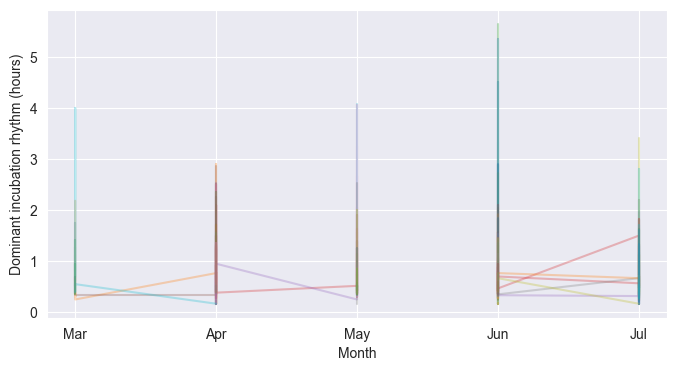

In [18]:
plt.figure(figsize=(8,4))

for nest, g in period_df.groupby("Nest_ID"):
    g = g.sort_values("Month")
    plt.plot(g["Month"], g["Period_hours"], alpha=0.3)

plt.xlabel("Month")
plt.ylabel("Dominant incubation rhythm (hours)")
plt.xticks([3,4,5,6,7], ["Mar","Apr","May","Jun","Jul"])

plt.show()

In [19]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

period_df["Month_name"] = pd.Categorical(
    period_df["Month_name"],
    categories=month_order,
    ordered=True
)

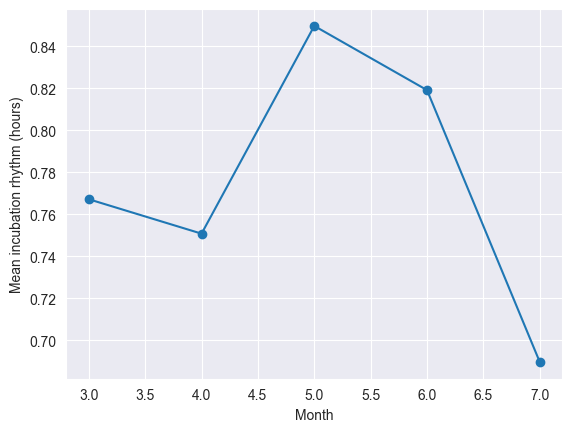

In [20]:
monthly_mean = (
    period_df
    .groupby("Month")["Period_hours"]
    .mean()
    .reset_index()
)

plt.plot(monthly_mean["Month"], monthly_mean["Period_hours"], marker="o")

plt.xlabel("Month")
plt.ylabel("Mean incubation rhythm (hours)")
plt.show()

## S3.5 Mixed-Effects Models of Seasonal Rhythm Change

To quantify seasonal trends statistically, mixed-effects models were fitted with nest identity as a random intercept.

Three response variables describing rhythm structure were analysed:

- dominant incubation period (hours)
- periodicity strength
- spectral entropy

Each variable was modelled as a function of day-of-year to evaluate how incubation rhythms change across the breeding season.

<Figure size 800x400 with 0 Axes>

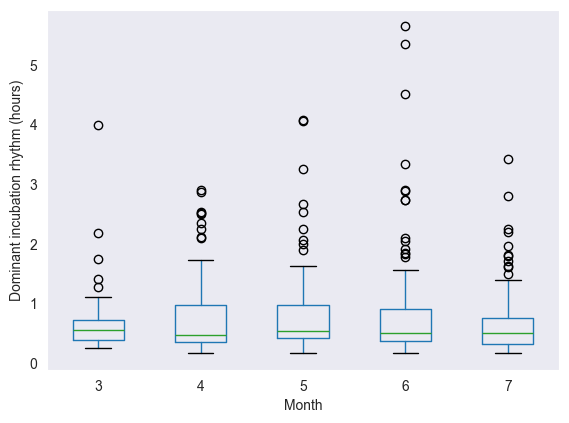

In [21]:
plt.figure(figsize=(8,4))

period_df.boxplot(
    column="Period_hours",
    by="Month",
    grid=False
)

plt.ylabel("Dominant incubation rhythm (hours)")
plt.xlabel("Month")
plt.title("")
plt.suptitle("")
plt.show()

<Figure size 800x400 with 0 Axes>

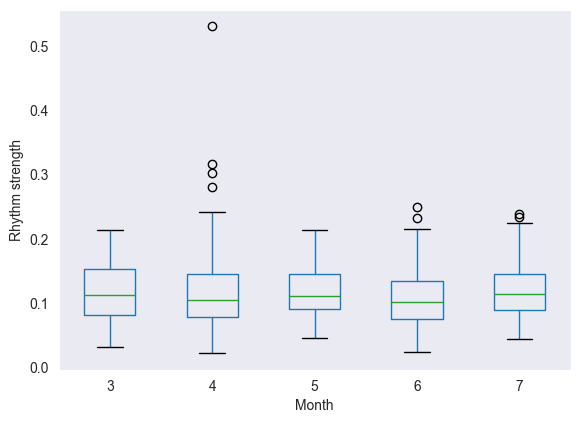

In [22]:
plt.figure(figsize=(8,4))

period_df.boxplot(
    column="Periodicity_strength",
    by="Month",
    grid=False
)

plt.ylabel("Rhythm strength")
plt.xlabel("Month")
plt.title("")
plt.suptitle("")
plt.show()

<Figure size 800x400 with 0 Axes>

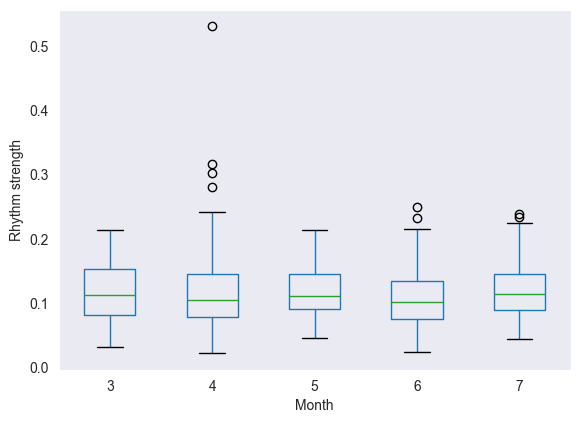

In [23]:
plt.figure(figsize=(8,4))

period_df.boxplot(
    column="Periodicity_strength",
    by="Month",
    grid=False
)

plt.ylabel("Rhythm strength")
plt.xlabel("Month")
plt.title("")
plt.suptitle("")
plt.show()

The final mixed models regress Period_hours, Periodicity_strength, and Spectral_entropy on day-of-year while nesting by Nest_ID, capturing how rhythm frequency and coherence evolve through the season.

In [24]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

In [25]:
period_df["DOY"] = period_df["Day"].dt.dayofyear

In [26]:

model_period_mixed = smf.mixedlm(
    "Period_hours ~ DOY",
    data=period_df,
    groups=period_df["Nest_ID"]
).fit()

print(model_period_mixed.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Period_hours
No. Observations: 519     Method:             REML        
No. Groups:       81      Scale:              0.4954      
Min. group size:  1       Log-Likelihood:     -572.7542   
Max. group size:  11      Converged:          No          
Mean group size:  6.4                                     
-----------------------------------------------------------
            Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept    0.816     0.152   5.369  0.000   0.518   1.114
DOY         -0.000     0.001  -0.257  0.797  -0.002   0.002
Group Var    0.025     0.030                               



Mixed-effects models showed no evidence that the dominant incubation rhythm changed across the breeding season. The estimated dominant cycle length averaged approximately 0.82 hours (≈49 minutes) and did not vary with day of year (β = −0.000, SE = 0.001, z = −0.26, p = 0.797). Variation among nests was minimal, indicating that incubation cycles were broadly consistent across individuals.

In [27]:
model_Periodicity_mixed = smf.mixedlm(
    "Periodicity_strength ~ DOY",
    data=period_df,
    groups=period_df["Nest_ID"]
).fit()

print(model_Periodicity_mixed.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Periodicity_strength
No. Observations: 519     Method:             REML                
No. Groups:       81      Scale:              0.0021              
Min. group size:  1       Log-Likelihood:     817.1570            
Max. group size:  11      Converged:          Yes                 
Mean group size:  6.4                                             
--------------------------------------------------------------------
                Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
--------------------------------------------------------------------
Intercept        0.125      0.013    9.787   0.000    0.100    0.150
DOY             -0.000      0.000   -0.801   0.423   -0.000    0.000
Group Var        0.000      0.003                                   



The strength of the dominant incubation rhythm also remained stable through the breeding season. Periodicity strength averaged 0.125 (SE = 0.013) and showed no relationship with day of year (β = −0.000, SE < 0.001, z = −0.80, p = 0.423). This suggests that the regularity of incubation cycles did not systematically increase or decrease as the season progressed.

In [28]:
model_Spectral_mixed = smf.mixedlm(
    "Spectral_entropy ~ DOY",
    data=period_df,
    groups=period_df["Nest_ID"]
).fit()

print(model_Spectral_mixed.summary())

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Spectral_entropy
No. Observations: 519     Method:             REML            
No. Groups:       81      Scale:              0.0863          
Min. group size:  1       Log-Likelihood:     -149.2228       
Max. group size:  11      Converged:          Yes             
Mean group size:  6.4                                         
----------------------------------------------------------------
             Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
----------------------------------------------------------------
Intercept    4.679      0.093   50.191   0.000    4.496    4.862
DOY          0.000      0.001    0.581   0.561   -0.001    0.002
Group Var    0.024      0.023                                   



Similarly, spectral entropy, representing the distribution of temporal frequencies in incubation behaviour, did not vary with seasonal timing. Mean entropy was 4.68 (SE = 0.09), and the effect of day of year was negligible (β = 0.000, SE = 0.001, z = 0.58, p = 0.561). These results indicate that the complexity of incubation timing remained relatively constant across the breeding season.

## Variable glossary

- **Nest_ID**: the unique nest code extracted from each _analizado_finale file.
- **Día**: calendar date of every bout and the unit that frames the daily signals.
- **Duración (min)**: bout duration in minutes used to compute coverage and to build the performance profile.
- **daily_signals**: 1,440-length binary traces per nest-day that mark On/Noct activity for spectral analysis.
- **Period_minutes** / **Period_hours**: lag-based estimates of the dominant incubation period per day derived from the autocorrelation peak.
- **Periodicity_strength**: proportion of spectral power explained by the dominant frequency, signalling rhythm regularity.
- **Spectral_entropy**: Shannon-style entropy of the power spectrum that measures how noisy or deterministic the pattern is.
- **Month** / **Month_name**: month labels created for visualizing trends across the breeding season.
- **DOY**: day-of-year integer used in the nested mixed models to capture seasonality.